# 01 — Exploratory data analysis

Load, clean, sanity-check, and persist the international results.

In [1]:
import sys; sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_results, clean_results

raw = load_results("../data/raw/results.csv")
df = clean_results(raw)
print(df.shape)
df.head()

(49405, 7)


,date,home_team,away_team,home_score,away_score,tournament,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,False
1,1873-03-08,England,Scotland,4,2,Friendly,False
2,1874-03-07,Scotland,England,2,1,Friendly,False
3,1875-03-06,England,Scotland,2,2,Friendly,False
4,1876-03-04,Scotland,England,3,0,Friendly,False


In [2]:
assert df["home_score"].min() >= 0 and df["away_score"].min() >= 0
print("date range:", df["date"].min().date(), "->", df["date"].max().date())
print("matches:", len(df), "| unique teams:", len(set(df.home_team) | set(df.away_team)))
df["tournament"].value_counts().head(10)

date range: 1872-11-30 -> 2026-06-10
matches: 49405 | unique teams: 335


tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

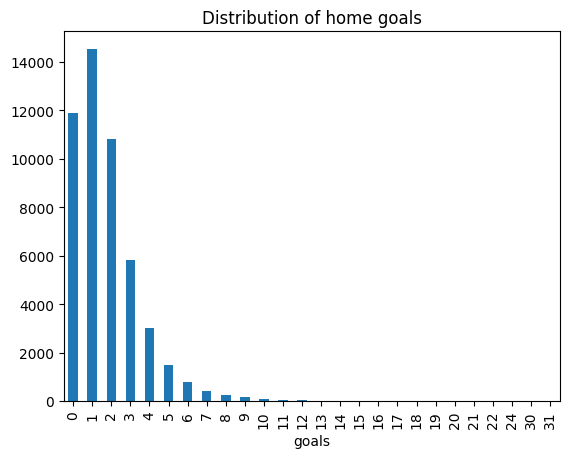

mean home goals: 1.757
mean away goals: 1.182


In [3]:
ax = df["home_score"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribution of home goals"); ax.set_xlabel("goals"); plt.show()
print("mean home goals:", round(df["home_score"].mean(), 3))
print("mean away goals:", round(df["away_score"].mean(), 3))

In [4]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_parquet("../data/processed/matches.parquet")
print("saved", len(df), "rows")

saved 49405 rows
